# Shoaling Trajectory Grid

Fast 5x7 trajectory-grid view for one 35-fish selection experiment. This notebook uses the slim selection notebook's `processingSettings.csv` as an experiment index and reads only the requested raw x/y trajectory columns.

## Settings

In [1]:
from pathlib import Path
import glob
import hashlib
import json
import math
import os
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_candidate = Path.cwd()
if repo_candidate.name == 'Analyses':
    repo_candidate = repo_candidate.parent
CODE_DIR = Path(os.environ.get('JLSOCIALBEHAVIOR_CODE_DIR', repo_candidate)).resolve()
os.chdir(CODE_DIR)

# Experiment index and animal metadata from the slim selection notebook. Edit these paths first for other datasets.
PROCESSING_SETTINGS_CSV = '//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp/shoaling_selection/ShoalSelec_temp_processing/processingSettings.csv'
META_FOLDER = '//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/07_Data/Carlos/Behavior/ShoalingSelection/'
META_FILE = 'MetaData_CR.xlsx'
OUTPUT_DIR = '//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp/shoaling_selection/ShoalSelec_temp_output/trajectory_grids/'

# Experiment selection. Folder wins when set; otherwise SELECT_EXPERIMENT_INDEX is used.
SELECT_EXPERIMENT_FOLDER = "20260313_01_35Animals_s2_TLSel1F10.1" #just the folder name, you don't need the full path. Set to None to use SELECT_EXPERIMENT_INDEX instead.
SELECT_EXPERIMENT_INDEX = 0

# Time window controls. Default is first 2 hours; set USE_FULL_RECORDING=True to ignore TIME_WINDOW_MIN.
TIME_WINDOW_MIN = (60, 90)
USE_FULL_RECORDING = False
FRAME_STRIDE = 30 # Carlos: Number of frames to skip between trajectory points. A value of 30 samples 1 frame per second. Set to 1 to use all frames, but this will be slow and probably not that informative.

# Data and output controls.
N_FISH = 35
FPS = 30
USE_TRAJECTORY_CACHE = True
SAVE_FIGURES = True
FIGURE_DPI = 180

# Absolute movement-density heatmap controls for outlier screening.
# Each heatmap bin stores the summed frame-to-frame path length whose midpoint falls in that bin.
# This makes the colors show where a fish spent movement effort, not just where positions were observed.
MOVEMENT_HEATMAP_BINS = 80
MOVEMENT_HEATMAP_CMAP = 'magma'
# Use one shared color scale across all 35 fish so bright panels are comparable.
# The 99th percentile avoids letting one extreme bin wash out the rest of the grid.
MOVEMENT_HEATMAP_VMAX_PERCENTILE = 99

os.makedirs(OUTPUT_DIR, exist_ok=True)
CACHE_DIR = os.path.join(OUTPUT_DIR, 'cache')
os.makedirs(CACHE_DIR, exist_ok=True)

print('Using repository:', CODE_DIR)
print('Using processing settings:', PROCESSING_SETTINGS_CSV)
print('Using animal metadata:', os.path.join(META_FOLDER, META_FILE))
print('Writing trajectory outputs to:', OUTPUT_DIR)

Using repository: C:\Users\crodri19\larschpostdoc_analyses\selection_shoaling\jlsocialbehavior
Using processing settings: //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp/shoaling_selection/ShoalSelec_temp_processing/processingSettings.csv
Using animal metadata: //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/07_Data/Carlos/Behavior/ShoalingSelection/MetaData_CR.xlsx
Writing trajectory outputs to: //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp/shoaling_selection/ShoalSelec_temp_output/trajectory_grids/


## Helpers

In [9]:
def safe_filename(value):
    text = str(value).strip()
    return ''.join(char if char.isalnum() or char in '._-' else '_' for char in text)


def parse_an_numbers(value, n_fish):
    text = str(value).strip()
    if not text or text.lower() == 'nan':
        return np.arange(n_fish)
    if ':' in text:
        start, stop = text.split(':', 1)
        values = np.arange(int(start), int(stop) + 1)
    else:
        values = np.array(re.split(r'[\s,]+', text), dtype=int)
    if len(values) < n_fish:
        raise ValueError(f'Animal ID list has {len(values)} entries but N_FISH={n_fish}.')
    return values[:n_fish]


def local_animal_ids(row, n_fish):
    if 'anIDAll' in row and pd.notna(row['anIDAll']):
        return parse_an_numbers(row['anIDAll'], n_fish)
    if 'anNr' in row and pd.notna(row['anNr']):
        return parse_an_numbers(row['anNr'], n_fish)
    return np.arange(n_fish)


def read_animal_metadata(meta_folder, meta_file):
    meta_path = os.path.join(meta_folder, meta_file)
    if not os.path.exists(meta_path):
        warnings.warn('Animal metadata file not found; subplot genotypes will be marked unknown: ' + meta_path)
        return pd.DataFrame(columns=['anNr', 'genotype'])
    return pd.read_excel(meta_path, sheet_name='AllAn')


def genotype_labels_for_animals(animal_ids, animal_metadata):
    if animal_metadata is None or animal_metadata.empty:
        return np.array(['unknown'] * len(animal_ids), dtype=object)
    missing_cols = {'anNr', 'genotype'} - set(animal_metadata.columns)
    if missing_cols:
        raise ValueError('Animal metadata is missing required columns: ' + ', '.join(sorted(missing_cols)))

    metadata = animal_metadata[['anNr', 'genotype']].copy()
    metadata['anNr'] = pd.to_numeric(metadata['anNr'], errors='coerce')
    metadata = metadata.dropna(subset=['anNr']).drop_duplicates('anNr', keep='last')
    genotype_by_animal = metadata.set_index('anNr')['genotype']

    labels = []
    for animal_id in animal_ids:
        animal_key = pd.to_numeric(pd.Series([animal_id]), errors='coerce').iloc[0]
        genotype = genotype_by_animal.get(animal_key, np.nan)
        if pd.isna(genotype) or str(genotype).strip() == '':
            labels.append('unknown')
        else:
            labels.append(str(genotype).strip())
    return np.asarray(labels, dtype=object)


def load_data_flex_delim(path, **kwargs):
    try:
        return np.loadtxt(path, **kwargs)
    except Exception:
        return np.loadtxt(path, delimiter=',', **kwargs)


def first_existing(patterns):
    for pattern in patterns:
        matches = sorted(glob.glob(pattern))
        if matches:
            return matches[0]
    return None


def resolve_scale_and_centers(row, n_fish):
    txt_path = str(row['txtPath'])
    arena_diameter_mm = float(row.get('arenaDiameter_mm', 70))
    start_dir = os.path.dirname(txt_path)

    roi_path = first_existing([os.path.join(start_dir, 'ROIdef*')])
    if roi_path is not None:
        rois = np.atleast_2d(load_data_flex_delim(roi_path))
        radii_px = rois[:n_fish, -1].astype(float)
        px_per_mm = 2 * np.nanmean(radii_px) / arena_diameter_mm
        centers_px = radii_px + 2
        return px_per_mm, centers_px, arena_diameter_mm / 2, roi_path

    roi_path = first_existing([
        os.path.join(start_dir, 'bgMed_scale*'),
        os.path.join(start_dir, '*bgMed.csv'),
    ])
    if roi_path is not None:
        rois = np.atleast_2d(np.loadtxt(roi_path, skiprows=1, delimiter=','))
        radius_col = 3 if rois.shape[1] > 3 else -1
        radii_px = rois[:n_fish, radius_col].astype(float)
        px_per_mm = 2 * np.nanmean(radii_px) / arena_diameter_mm
        centers_px = radii_px + 2
        return px_per_mm, centers_px, arena_diameter_mm / 2, roi_path

    if 'pxPmm' in row and pd.notna(row['pxPmm']):
        warnings.warn('No ROI file found; using pxPmm and leaving coordinates uncentered.')
        return float(row['pxPmm']), np.zeros(n_fish), arena_diameter_mm / 2, 'pxPmm column'

    raise FileNotFoundError('No ROI file or pxPmm value found for ' + txt_path)


def frame_window(time_window_min, use_full_recording, fps):
    if use_full_recording:
        return 0, None, 'full_recording'
    if time_window_min is None:
        return 0, None, 'full_recording'
    start_min, stop_min = time_window_min
    if start_min < 0 or stop_min <= start_min:
        raise ValueError('TIME_WINDOW_MIN must be a (start, stop) tuple in minutes.')
    start_frame = int(round(start_min * 60 * fps))
    stop_frame = int(round(stop_min * 60 * fps))
    return start_frame, stop_frame - start_frame, f'{start_min:g}-{stop_min:g}_min'


def raw_file_mtime(path):
    try:
        return os.path.getmtime(path)
    except OSError:
        return None


def trajectory_cache_path(row, start_frame, n_rows, frame_stride, n_fish):
    txt_path = str(row['txtPath'])
    experiment_label = row.get('folder', Path(txt_path).stem)
    key = {
        'txt_path': txt_path,
        'txt_stem': Path(txt_path).stem,
        'experiment_label': str(experiment_label),
        'start_frame': start_frame,
        'n_rows': n_rows,
        'frame_stride': int(frame_stride),
        'n_fish': int(n_fish),
        'mtime': raw_file_mtime(txt_path),
    }
    digest = hashlib.sha1(json.dumps(key, sort_keys=True, default=str).encode('utf-8')).hexdigest()[:12]
    label = safe_filename(f'{experiment_label}_{Path(txt_path).stem}_{digest}')
    return os.path.join(CACHE_DIR, label + '.npz'), key


def read_fast_xy_window(txt_path, n_fish, start_frame=0, n_rows=None, frame_stride=1):
    txt_path = str(txt_path)
    xy_cols = [col for fish in range(n_fish) for col in (fish * 3, fish * 3 + 1)]

    if txt_path[-3:].lower() == 'npy':
        raw = np.load(txt_path)
        stop = None if n_rows is None else start_frame + n_rows
        return raw[start_frame:stop:frame_stride, :n_fish, :2].astype(float)

    first_line = pd.read_csv(txt_path, header=None, nrows=1, sep=':')
    first_value = str(first_line.values[0][0])
    first_char = first_value[0] if first_value else ''

    if first_char == '(':
        raise ValueError('Old Bonsai format is not supported by this fast 35-fish trajectory reader.')
    if first_char == 'X':
        skiprows = [0] + list(range(1, start_frame + 1)) if start_frame else [0]
    else:
        skiprows = range(start_frame) if start_frame else None

    raw_xy = pd.read_csv(
        txt_path,
        header=None,
        delim_whitespace=True,
        usecols=xy_cols,
        skiprows=skiprows,
        nrows=n_rows,
    ).to_numpy(dtype=float)
    raw_xy = raw_xy[::frame_stride]
    return raw_xy.reshape(raw_xy.shape[0], n_fish, 2)


def load_or_build_trajectory(row, n_fish, time_window_min, use_full_recording, frame_stride, fps):
    start_frame, n_rows, window_label = frame_window(time_window_min, use_full_recording, fps)
    cache_path, cache_key = trajectory_cache_path(row, start_frame, n_rows, frame_stride, n_fish)

    if USE_TRAJECTORY_CACHE and os.path.exists(cache_path):
        cached = np.load(cache_path, allow_pickle=False)
        meta = json.loads(str(cached['meta_json']))
        print('Loaded cached trajectory window:', cache_path)
        return cached['xy_mm'], cached['animal_ids'], float(cached['arena_radius_mm']), meta, cache_path

    px_per_mm, centers_px, arena_radius_mm, scale_source = resolve_scale_and_centers(row, n_fish)
    raw_xy = read_fast_xy_window(row['txtPath'], n_fish, start_frame, n_rows, frame_stride)
    xy_mm = (raw_xy - centers_px[np.newaxis, :, np.newaxis]) / px_per_mm
    animal_ids = local_animal_ids(row, n_fish)
    meta = {
        'folder': str(row.get('folder', '')),
        'txt_path': str(row['txtPath']),
        'txt_stem': Path(str(row['txtPath'])).stem,
        'window_label': window_label,
        'start_frame': start_frame,
        'n_rows_requested': n_rows,
        'frame_stride': int(frame_stride),
        'fps': int(fps),
        'px_per_mm': float(px_per_mm),
        'scale_source': str(scale_source),
        'cache_key': cache_key,
    }

    if USE_TRAJECTORY_CACHE:
        np.savez_compressed(
            cache_path,
            xy_mm=xy_mm,
            animal_ids=np.asarray(animal_ids),
            arena_radius_mm=np.asarray(arena_radius_mm),
            meta_json=np.asarray(json.dumps(meta, default=str, sort_keys=True)),
        )
        print('Cached trajectory window:', cache_path)
    else:
        print('Trajectory cache disabled; parsed raw trajectory file.')

    return xy_mm, np.asarray(animal_ids), float(arena_radius_mm), meta, cache_path


def plot_trajectory_grid(xy_mm, animal_ids, arena_radius_mm, meta, output_dir, save_figures=True, animal_genotypes=None):
    n_fish = xy_mm.shape[1]
    n_rows, n_cols = 5, 7
    if n_fish != n_rows * n_cols:
        raise ValueError(f'Expected {n_rows * n_cols} fish for a 5x7 grid, got {n_fish}.')
    if animal_genotypes is None:
        animal_genotypes = ['unknown'] * n_fish
    if len(animal_genotypes) != n_fish:
        raise ValueError(f'Expected {n_fish} genotype labels, got {len(animal_genotypes)}.')

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 10), sharex=True, sharey=True, dpi=FIGURE_DPI)
    limit = max(arena_radius_mm * 1.05, float(np.nanpercentile(np.abs(xy_mm), 99.5)) * 1.02)
    theta = np.linspace(0, 2 * np.pi, 181)
    circle_x = arena_radius_mm * np.cos(theta)
    circle_y = arena_radius_mm * np.sin(theta)

    for fish_idx, ax in enumerate(axes.ravel()):
        xy = xy_mm[:, fish_idx, :]
        ax.plot(xy[:, 0], xy[:, 1], color='#2D6F8E', lw=0.45, alpha=0.8, rasterized=True)
        ax.plot(circle_x, circle_y, color='0.25', lw=0.55, alpha=0.7)
        ax.axhline(0, color='0.8', lw=0.35, zorder=0)
        ax.axvline(0, color='0.8', lw=0.35, zorder=0)
        ax.set_xlim(-limit, limit)
        ax.set_ylim(-limit, limit)
        ax.set_aspect('equal', adjustable='box')
        genotype = str(animal_genotypes[fish_idx]).strip() or 'unknown'
        ax.set_title(f'{fish_idx:02d} | an {animal_ids[fish_idx]}\ngenotype: {genotype}', fontsize=7)
        ax.tick_params(labelsize=6, length=2)

    for ax in axes[-1, :]:
        ax.set_xlabel('x (mm)', fontsize=8)
    for ax in axes[:, 0]:
        ax.set_ylabel('y (mm)', fontsize=8)

    folder = meta.get('folder') or meta.get('txt_stem', '')
    fig.suptitle(
        f'Trajectories: {folder} | {meta.get("window_label", "window")} | stride {meta.get("frame_stride")}',
        fontsize=12,
        y=0.995,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.97])

    output_base = os.path.join(output_dir, safe_filename(f'trajectory_grid_{folder}_{meta.get("window_label", "window")}'))
    if save_figures:
        fig.savefig(output_base + '.png', dpi=FIGURE_DPI, bbox_inches='tight')
        fig.savefig(output_base + '.pdf', bbox_inches='tight')
        print('Wrote:', output_base + '.png')
        print('Wrote:', output_base + '.pdf')
    return fig


def validate_subplot_labels(animal_ids, animal_genotypes):
    n_fish = len(animal_ids)
    if animal_genotypes is None:
        animal_genotypes = ['unknown'] * n_fish
    if len(animal_genotypes) != n_fish:
        raise ValueError(f'Expected {n_fish} genotype labels, got {len(animal_genotypes)}.')
    return np.asarray(animal_genotypes, dtype=object)


def robust_movement_z(values):
    """Return a robust z-score based on the median absolute deviation.

    zMAD is used here instead of a mean/standard-deviation z-score because one
    unusually active or inactive fish can strongly bias the mean and standard
    deviation in a 35-fish experiment. The score is centered on the cohort
    median movement rate. Positive values mean more movement than the median;
    negative values mean less movement than the median. The 0.6745 factor puts
    MAD on approximately the same scale as a standard z-score when the values
    are normally distributed.
    """
    values = pd.Series(values, dtype='float64')
    median = values.median(skipna=True)
    mad = (values - median).abs().median(skipna=True)
    if pd.isna(mad) or mad == 0:
        # If all movement rates are identical, there is no robust spread to scale by.
        return pd.Series(np.zeros(len(values)), index=values.index, dtype='float64')
    return 0.6745 * (values - median) / mad


def movement_heatmaps_and_metrics(xy_mm, animal_ids, animal_genotypes, arena_radius_mm, bins, fps, frame_stride):
    """Build per-fish movement-density heatmaps and the matching metrics table.

    Parameters are already in millimeters and already restricted to the chosen
    time window. For each fish, every valid pair of consecutive sampled points
    contributes its step distance to the spatial bin containing the step midpoint.
    The returned heatmaps therefore answer: where in the arena did this fish
    travel distance during this window?
    """
    n_fish = xy_mm.shape[1]
    animal_genotypes = validate_subplot_labels(animal_ids, animal_genotypes)
    # Use a common square extent for every panel so the fish can be compared visually.
    # The arena radius anchors the plot, while the trajectory percentile keeps rare
    # off-arena tracking points from forcing a very large empty plotting area.
    limit = max(arena_radius_mm * 1.05, float(np.nanpercentile(np.abs(xy_mm), 99.5)) * 1.02)
    edges = np.linspace(-limit, limit, bins + 1)
    centers = (edges[:-1] + edges[1:]) / 2
    grid_x, grid_y = np.meshgrid(centers, centers)
    # Bins outside the circular arena are masked so they draw as empty background.
    inside_arena = (grid_x ** 2 + grid_y ** 2) <= arena_radius_mm ** 2
    # FRAME_STRIDE changes the time between sampled points; this converts valid
    # step counts back into real elapsed time for mm/min and mm/s metrics.
    sample_seconds = float(frame_stride) / float(fps)

    heatmaps = np.full((n_fish, bins, bins), np.nan)
    metric_rows = []
    for fish_idx in range(n_fish):
        xy = xy_mm[:, fish_idx, :]
        valid_positions = np.isfinite(xy).all(axis=1)
        # Consecutive sampled positions define one movement step.
        # Step midpoints decide which heatmap bin receives that movement distance.
        steps = xy[1:] - xy[:-1]
        step_midpoints = (xy[1:] + xy[:-1]) / 2
        step_distance = np.sqrt(np.sum(steps ** 2, axis=1))
        valid_steps = np.isfinite(step_midpoints).all(axis=1) & np.isfinite(step_distance)
        # Zero-length steps add no movement information and would only inflate duration.
        valid_steps &= step_distance > 0

        hist, _, _ = np.histogram2d(
            step_midpoints[valid_steps, 0],
            step_midpoints[valid_steps, 1],
            bins=[edges, edges],
            # Weighting by distance turns the histogram into movement density.
            # A frequently crossed bin becomes bright even if the fish did not pause there.
            weights=step_distance[valid_steps]
        )
        # histogram2d returns [x_bin, y_bin]; transpose to align with imshow rows as y.
        heatmap = hist.T
        heatmap[~inside_arena] = np.nan
        heatmaps[fish_idx] = heatmap

        total_distance_mm = float(np.nansum(step_distance[valid_steps]))
        valid_duration_min = float(valid_steps.sum() * sample_seconds / 60)
        distance_per_min = total_distance_mm / valid_duration_min if valid_duration_min > 0 else np.nan
        mean_speed_mm_s = total_distance_mm / (valid_duration_min * 60) if valid_duration_min > 0 else np.nan
        # Coverage is the fraction of in-arena bins that received any movement distance.
        # It is a coarse spatial spread metric, separate from how far the fish traveled.
        arena_coverage_fraction = float(np.count_nonzero(np.nan_to_num(heatmap) > 0) / inside_arena.sum())
        # Table columns:
        # - fish_idx: subplot/local fish index, 0 to 34.
        # - animal_id and genotype: labels loaded from metadata for this fish.
        # - valid_samples: finite x/y positions in the selected trajectory window.
        # - valid_intervals: finite nonzero movement steps used for distance and heatmap bins.
        # - valid_duration_min: valid_intervals converted to minutes using fps and stride.
        # - total_distance_mm: summed valid step distances across the selected window.
        # - distance_per_min: total_distance_mm normalized by valid_duration_min.
        # - mean_speed_mm_s: same movement rate expressed in mm/s.
        # - arena_coverage_fraction: fraction of circular arena bins touched by movement.
        metric_rows.append({
            'fish_idx': fish_idx,
            'animal_id': animal_ids[fish_idx],
            'genotype': str(animal_genotypes[fish_idx]).strip() or 'unknown',
            'valid_samples': int(valid_positions.sum()),
            'valid_intervals': int(valid_steps.sum()),
            'valid_duration_min': valid_duration_min,
            'total_distance_mm': total_distance_mm,
            'distance_per_min': distance_per_min,
            'mean_speed_mm_s': mean_speed_mm_s,
            'arena_coverage_fraction': arena_coverage_fraction,
        })

    metrics = pd.DataFrame(metric_rows)
    # movement_z_mad compares each fish's mm/min rate with the cohort median:
    # zMAD = 0.6745 * (distance_per_min - median(distance_per_min)) / MAD.
    # movement_z_mad_abs ignores direction and is useful for ranking both unusually
    # high-movement and unusually low-movement fish for manual inspection.
    metrics['movement_z_mad'] = robust_movement_z(metrics['distance_per_min'])
    metrics['movement_z_mad_abs'] = metrics['movement_z_mad'].abs()
    extent = [-limit, limit, -limit, limit]
    return heatmaps, metrics, extent


def plot_movement_heatmap_grid(
    xy_mm,
    animal_ids,
    arena_radius_mm,
    meta,
    output_dir,
    save_figures=True,
    animal_genotypes=None,
    bins=MOVEMENT_HEATMAP_BINS,
    cmap=MOVEMENT_HEATMAP_CMAP,
    vmax_percentile=MOVEMENT_HEATMAP_VMAX_PERCENTILE,
):
    n_fish = xy_mm.shape[1]
    n_rows, n_cols = 5, 7
    if n_fish != n_rows * n_cols:
        raise ValueError(f'Expected {n_rows * n_cols} fish for a 5x7 grid, got {n_fish}.')

    # Compute all heatmap arrays first, then choose one color scale for the grid.
    # This keeps color intensity comparable across fish within the same experiment/window.
    heatmaps, metrics, extent = movement_heatmaps_and_metrics(
        xy_mm,
        animal_ids,
        animal_genotypes,
        arena_radius_mm,
        bins,
        fps=meta.get('fps', FPS),
        frame_stride=meta.get('frame_stride', FRAME_STRIDE),
    )
    # Only positive in-arena bins set vmax; empty/masked bins should not affect contrast.
    positive_values = heatmaps[np.isfinite(heatmaps) & (heatmaps > 0)]
    vmax = float(np.nanpercentile(positive_values, vmax_percentile)) if positive_values.size else 1.0
    if not np.isfinite(vmax) or vmax <= 0:
        vmax = 1.0

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 10), sharex=True, sharey=True, dpi=FIGURE_DPI)
    theta = np.linspace(0, 2 * np.pi, 181)
    circle_x = arena_radius_mm * np.cos(theta)
    circle_y = arena_radius_mm * np.sin(theta)
    im = None

    for fish_idx, ax in enumerate(axes.ravel()):
        # Masked NaNs are outside-arena bins; imshow draws them as blank background.
        im = ax.imshow(
            np.ma.masked_invalid(heatmaps[fish_idx]),
            origin='lower',
            extent=extent,
            cmap=cmap,
            vmin=0,
            vmax=vmax,
            interpolation='nearest',
            rasterized=True,
        )
        ax.plot(circle_x, circle_y, color='white', lw=0.55, alpha=0.8)
        ax.axhline(0, color='white', lw=0.25, alpha=0.35, zorder=2)
        ax.axvline(0, color='white', lw=0.25, alpha=0.35, zorder=2)
        ax.set_xlim(extent[0], extent[1])
        ax.set_ylim(extent[2], extent[3])
        ax.set_aspect('equal', adjustable='box')
        row = metrics.iloc[fish_idx]
        # The title repeats the two most useful screening numbers:
        # absolute movement rate (mm/min) and robust deviation from the cohort (zMAD).
        ax.set_title(
            f'{fish_idx:02d} | an {row["animal_id"]}\n'
            f'genotype: {row["genotype"]}\n'
            f'{row["distance_per_min"]:.0f} mm/min | zMAD {row["movement_z_mad"]:.1f}',
            fontsize=6.5,
        )
        ax.tick_params(labelsize=6, length=2)

    for ax in axes[-1, :]:
        ax.set_xlabel('x (mm)', fontsize=8)
    for ax in axes[:, 0]:
        ax.set_ylabel('y (mm)', fontsize=8)

    folder = meta.get('folder') or meta.get('txt_stem', '')
    fig.suptitle(
        f'Movement density: {folder} | {meta.get("window_label", "window")} | '
        f'stride {meta.get("frame_stride")} | shared vmax {vmax_percentile:g}th pct = {vmax:.1f} mm/bin',
        fontsize=12,
        y=0.995,
    )
    # Colorbar units match the weighted histogram: summed distance traveled per bin.
    fig.colorbar(
        im,
        ax=axes.ravel().tolist(),
        fraction=0.018,
        pad=0.01,
        label='distance traveled per bin (mm)',
    )
    fig.subplots_adjust(left=0.04, right=0.90, bottom=0.05, top=0.92, wspace=0.15, hspace=0.58)

    output_base = os.path.join(output_dir, safe_filename(f'movement_heatmap_grid_{folder}_{meta.get("window_label", "window")}'))
    if save_figures:
        # Save both the figure and the metrics table so visual outliers can be traced
        # back to exact movement rates, coverage, and metadata labels later.
        fig.savefig(output_base + '.png', dpi=FIGURE_DPI, bbox_inches='tight')
        fig.savefig(output_base + '.pdf', bbox_inches='tight')
        metrics.to_csv(output_base + '_metrics.csv', index=False)
        print('Wrote:', output_base + '.png')
        print('Wrote:', output_base + '.pdf')
        print('Wrote:', output_base + '_metrics.csv')
    return fig, metrics

## Select Experiment

In [3]:
experiments = pd.read_csv(PROCESSING_SETTINGS_CSV, index_col=0)
infoAn = read_animal_metadata(META_FOLDER, META_FILE)
if experiments.empty:
    raise ValueError('No experiments found in ' + PROCESSING_SETTINGS_CSV)

if SELECT_EXPERIMENT_FOLDER is not None:
    matches = experiments[experiments['folder'].astype(str) == str(SELECT_EXPERIMENT_FOLDER)]
    if matches.empty:
        raise ValueError(f'SELECT_EXPERIMENT_FOLDER not found: {SELECT_EXPERIMENT_FOLDER}')
    selected_row = matches.iloc[0]
    selected_index = matches.index[0]
else:
    selected_index = experiments.index[SELECT_EXPERIMENT_INDEX]
    selected_row = experiments.loc[selected_index]

preview_cols = [c for c in ['folder', 'date', 'setup', 'txtPath'] if c in experiments.columns]
display(experiments[preview_cols].reset_index().rename(columns={'index': 'processing_row'}).head(30))

print('Selected processing row:', selected_index)
print('Selected folder:', selected_row.get('folder', ''))
print('Raw trajectory file:', selected_row['txtPath'])

,processing_row,folder,date,setup,txtPath
0,0,20250128_01_35Animals_dn_TLSel1F9,28-01-2025,1,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...
1,1,20250513_01_35Animals_s1_TLSel3F7,13-05-2025,1,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...
2,2,20250513_02_35Animals_s2_TLSel3F7,13-05-2025,2,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...
3,3,20250618_01_35Animals_s1_TLSel1F10,18-06-2025,1,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...
4,4,20250618_02_35Animals_s2_TLSel1F10,18-06-2025,2,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...
5,5,20250701_01_35Animals_s1_TLSel1GC,01-07-2025,1,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...
6,6,20250701_02_35Animals_s2_TLSel1GC,01-07-2025,2,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...
7,7,20250728_01_35Animals_s1_TLSel1F10,28-07-2025,1,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...
8,8,20250728_02_35Animals_s2_TLSel1F10,28-07-2025,2,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...
9,9,20250729_01_35Animals_s1_TLSel3F8,29-07-2025,1,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...


Selected processing row: 25
Selected folder: 20260313_01_35Animals_s2_TLSel1F10.1
Raw trajectory file: \\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\07_Data\Carlos\Behavior\ShoalingSelection\20260313_01_35Animals_s2_TLSel1F10.1\PositionTxt_allROI2026-03-13T11_16_11.csv


## Load Trajectory Window

In [4]:
xy_mm, animal_ids, arena_radius_mm, trajectory_meta, trajectory_cache = load_or_build_trajectory(
    selected_row,
    n_fish=N_FISH,
    time_window_min=TIME_WINDOW_MIN,
    use_full_recording=USE_FULL_RECORDING,
    frame_stride=FRAME_STRIDE,
    fps=FPS,
)

print('xy_mm shape:', xy_mm.shape)
animal_genotypes = genotype_labels_for_animals(animal_ids, infoAn)

print('animal IDs:', animal_ids)
print('animal genotypes:', animal_genotypes)
print('arena radius (mm):', arena_radius_mm)
print('scale source:', trajectory_meta.get('scale_source'))

Loaded cached trajectory window: //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp/shoaling_selection/ShoalSelec_temp_output/trajectory_grids/cache\20260313_01_35Animals_s2_TLSel1F10.1_PositionTxt_allROI2026-03-13T11_16_11_9d39d5c9e03a.npz
xy_mm shape: (1800, 35, 2)
animal IDs: [876 877 878 879 880 881 882 883 884 885 886 887 888 889 890 891 892 893
 894 895 896 897 898 899 900 901 902 903 904 905 906 907 908 909 910]
animal genotypes: ['hi' 'lo' 'hi' 'lo' 'hi' 'lo' 'hi' 'lo' 'hi' 'lo' 'hi' 'lo' 'hi' 'lo'
 'hi' 'lo' 'hi' 'lo' 'hi' 'lo' 'hi' 'lo' 'hi' 'lo' 'hi' 'lo' 'hi' 'lo'
 'hi' 'lo' 'hi' 'lo' 'hi' 'lo' 'hi']
arena radius (mm): 35.0
scale source: \\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\07_Data\Carlos\Behavior\ShoalingSelection\20260313_01_35Animals_s2_TLSel1F10.1\ROIdef2026-03-13T09_55_13.csv


## Plot 5x7 Grid

Wrote: //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp/shoaling_selection/ShoalSelec_temp_output/trajectory_grids/trajectory_grid_20260313_01_35Animals_s2_TLSel1F10.1_60-90_min.png
Wrote: //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp/shoaling_selection/ShoalSelec_temp_output/trajectory_grids/trajectory_grid_20260313_01_35Animals_s2_TLSel1F10.1_60-90_min.pdf


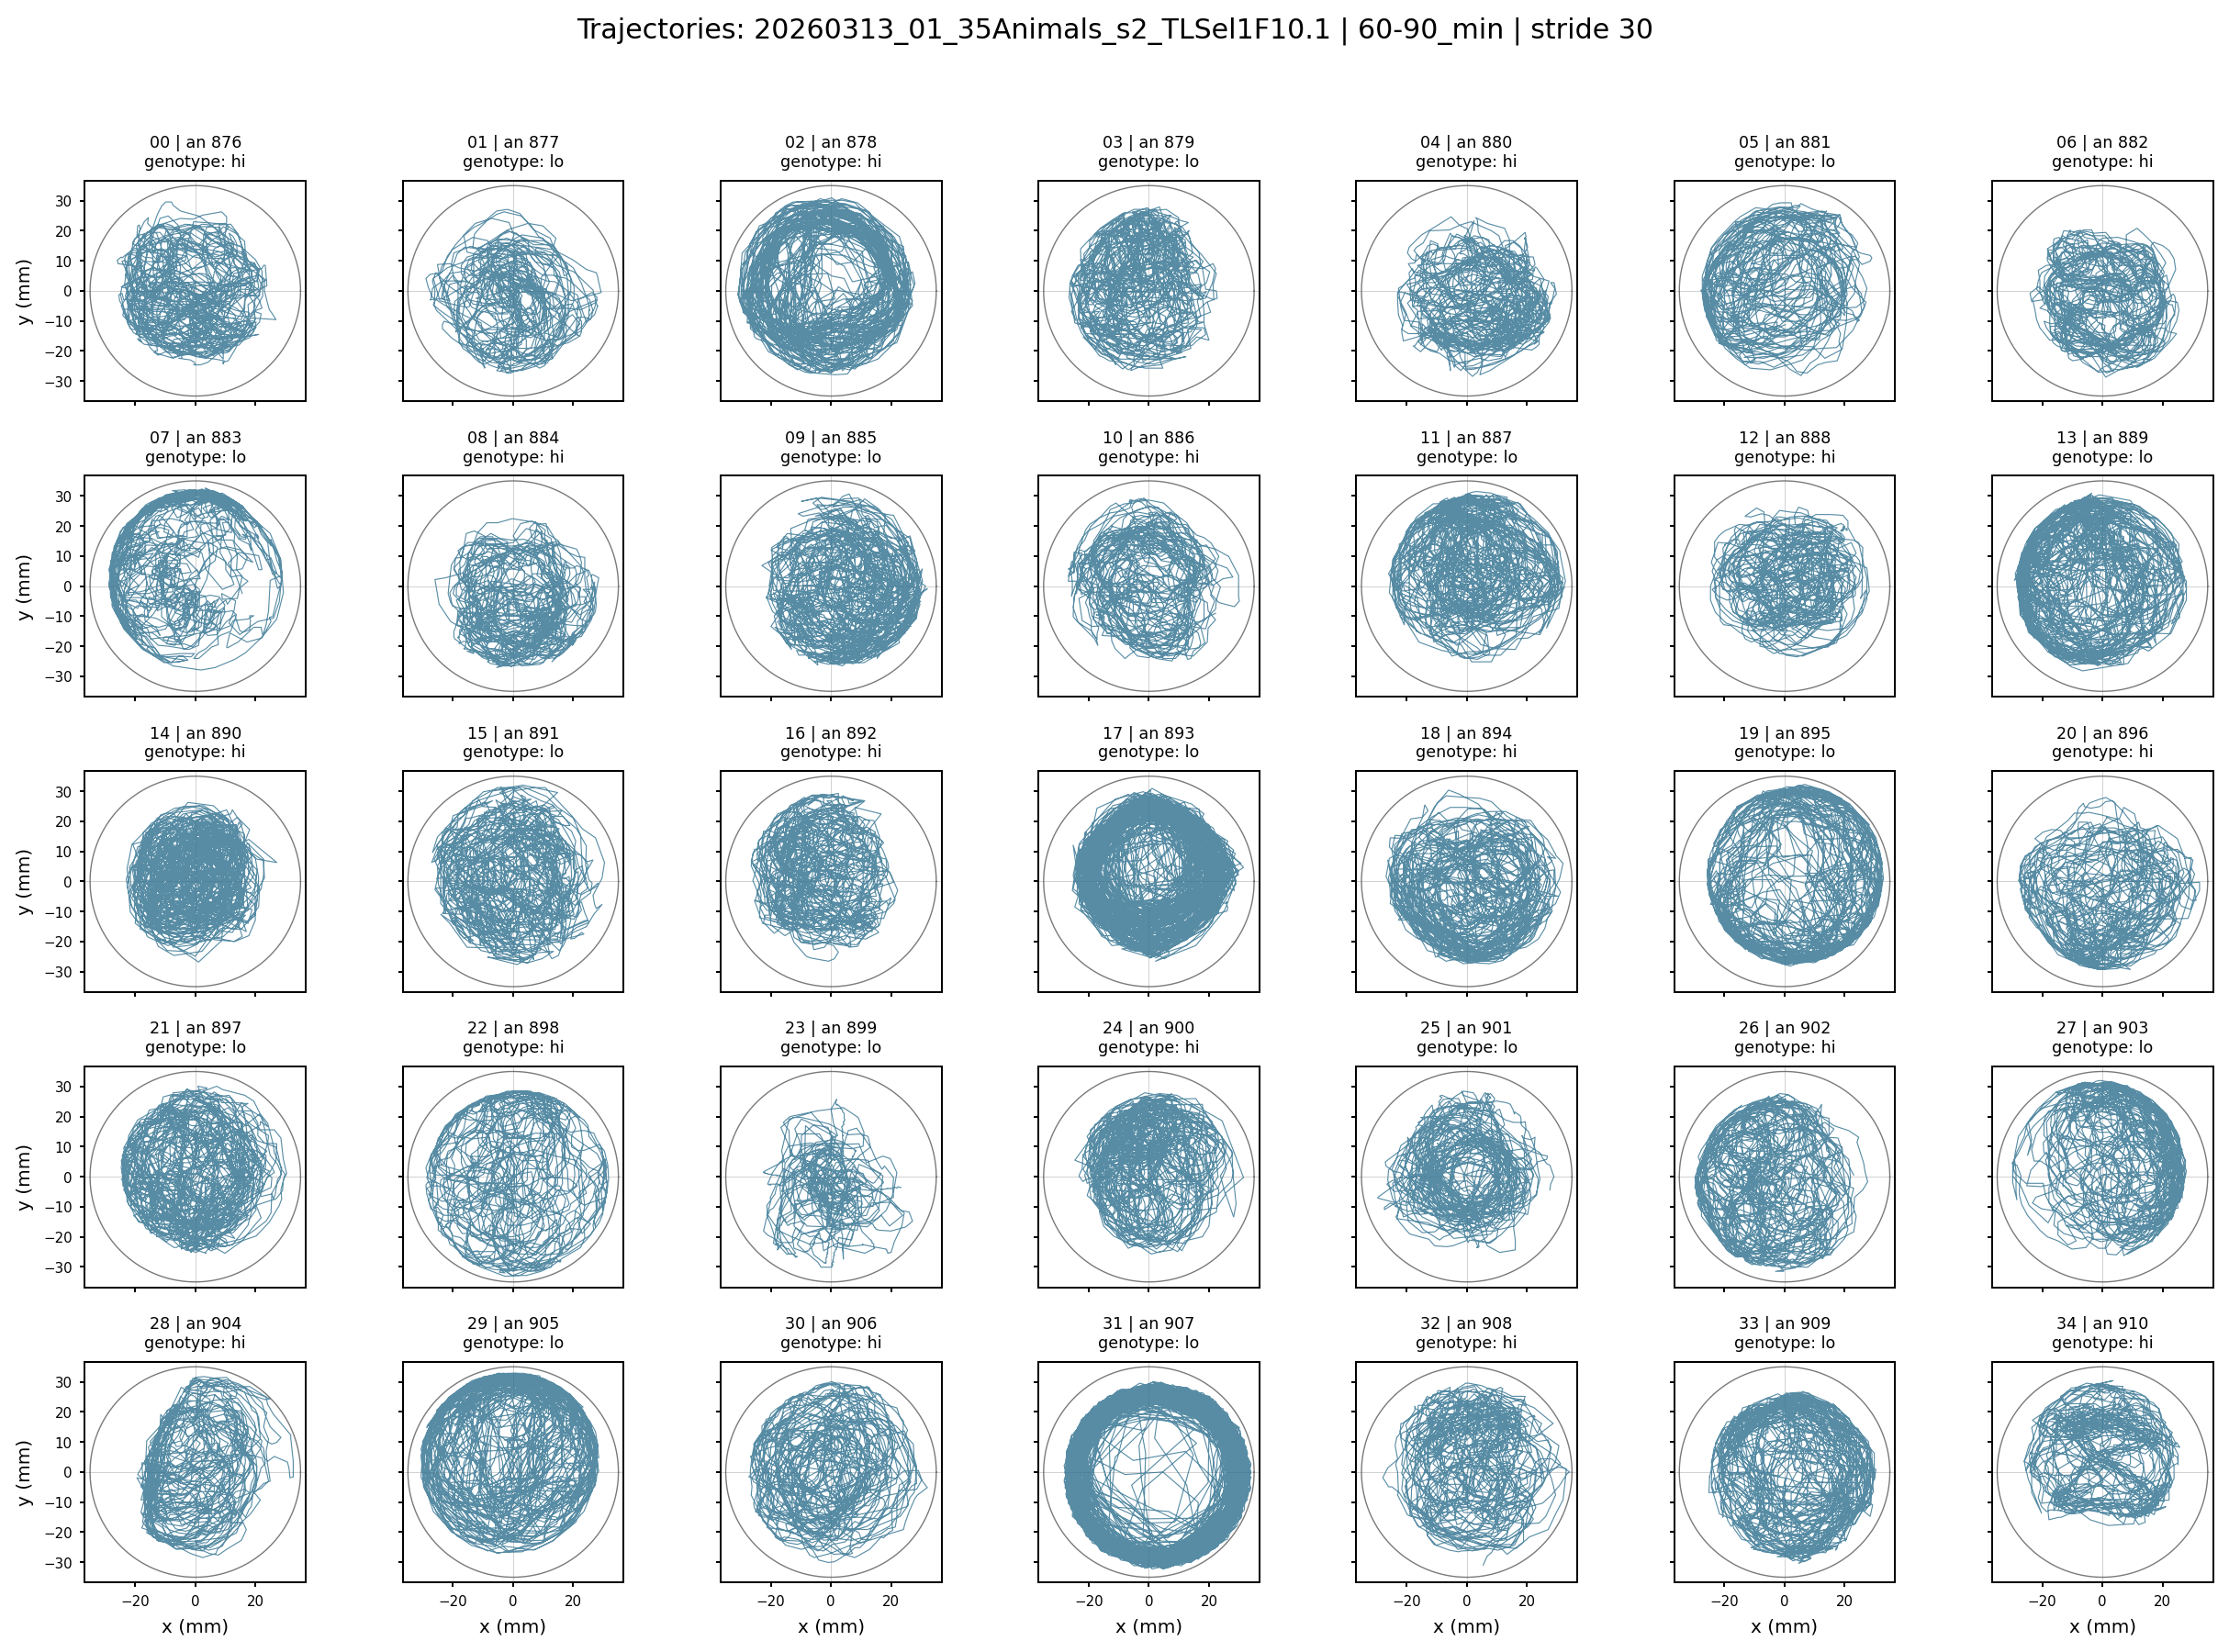

In [5]:
fig = plot_trajectory_grid(
    xy_mm,
    animal_ids,
    arena_radius_mm,
    trajectory_meta,
    OUTPUT_DIR,
    save_figures=SAVE_FIGURES,
    animal_genotypes=animal_genotypes,
)
plt.show()

## Plot 5x7 Movement Heatmap Grid

This grid converts each fish's sampled trajectory into an absolute movement-density heatmap. Each valid frame-to-frame step contributes its traveled distance, in millimeters, to the spatial bin at that step's midpoint. The table below is sorted by `movement_z_mad_abs`, so the strongest movement outliers appear first regardless of whether they moved much more or much less than the cohort median.

`movement_z_mad` is a robust MAD z-score for `distance_per_min`: `0.6745 * (fish_mm_per_min - cohort_median_mm_per_min) / MAD`. Positive values are more active than the median fish in this plotted window; negative values are less active. `movement_z_mad_abs` is the absolute value used only for ranking potential outliers.

Wrote: //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp/shoaling_selection/ShoalSelec_temp_output/trajectory_grids/movement_heatmap_grid_20260313_01_35Animals_s2_TLSel1F10.1_60-90_min.png
Wrote: //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp/shoaling_selection/ShoalSelec_temp_output/trajectory_grids/movement_heatmap_grid_20260313_01_35Animals_s2_TLSel1F10.1_60-90_min.pdf
Wrote: //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp/shoaling_selection/ShoalSelec_temp_output/trajectory_grids/movement_heatmap_grid_20260313_01_35Animals_s2_TLSel1F10.1_60-90_min_metrics.csv


,fish_idx,animal_id,genotype,valid_samples,valid_intervals,valid_duration_min,total_distance_mm,distance_per_min,mean_speed_mm_s,arena_coverage_fraction,movement_z_mad,movement_z_mad_abs
0,31,907,lo,1800,1799,29.983333,32968.065163,1099.546365,18.325773,0.229807,12.592651,12.592651
1,17,893,lo,1800,1759,29.316667,20954.767063,714.773180,11.912886,0.260975,6.908215,6.908215
2,2,878,hi,1800,1799,29.983333,12955.053233,432.075150,7.201252,0.282046,2.731783,2.731783
3,29,905,lo,1800,1797,29.950000,12724.380961,424.854122,7.080902,0.280729,2.625104,2.625104
4,13,889,lo,1800,1799,29.983333,12196.290543,406.769001,6.779483,0.276558,2.357924,2.357924
5,14,890,hi,1800,1797,29.950000,10635.315657,355.102359,5.918373,0.250658,1.594628,1.594628
6,23,899,lo,1800,1391,23.183333,3326.258297,143.476274,2.391271,0.156716,-1.531824,1.531824
7,19,895,lo,1800,1799,29.983333,10295.316982,343.367993,5.722800,0.276339,1.421271,1.421271
8,11,887,lo,1800,1798,29.966667,10012.024782,334.105388,5.568423,0.278973,1.284430,1.284430
9,9,885,lo,1800,1791,29.850000,9875.448518,330.835796,5.513930,0.278095,1.236127,1.236127


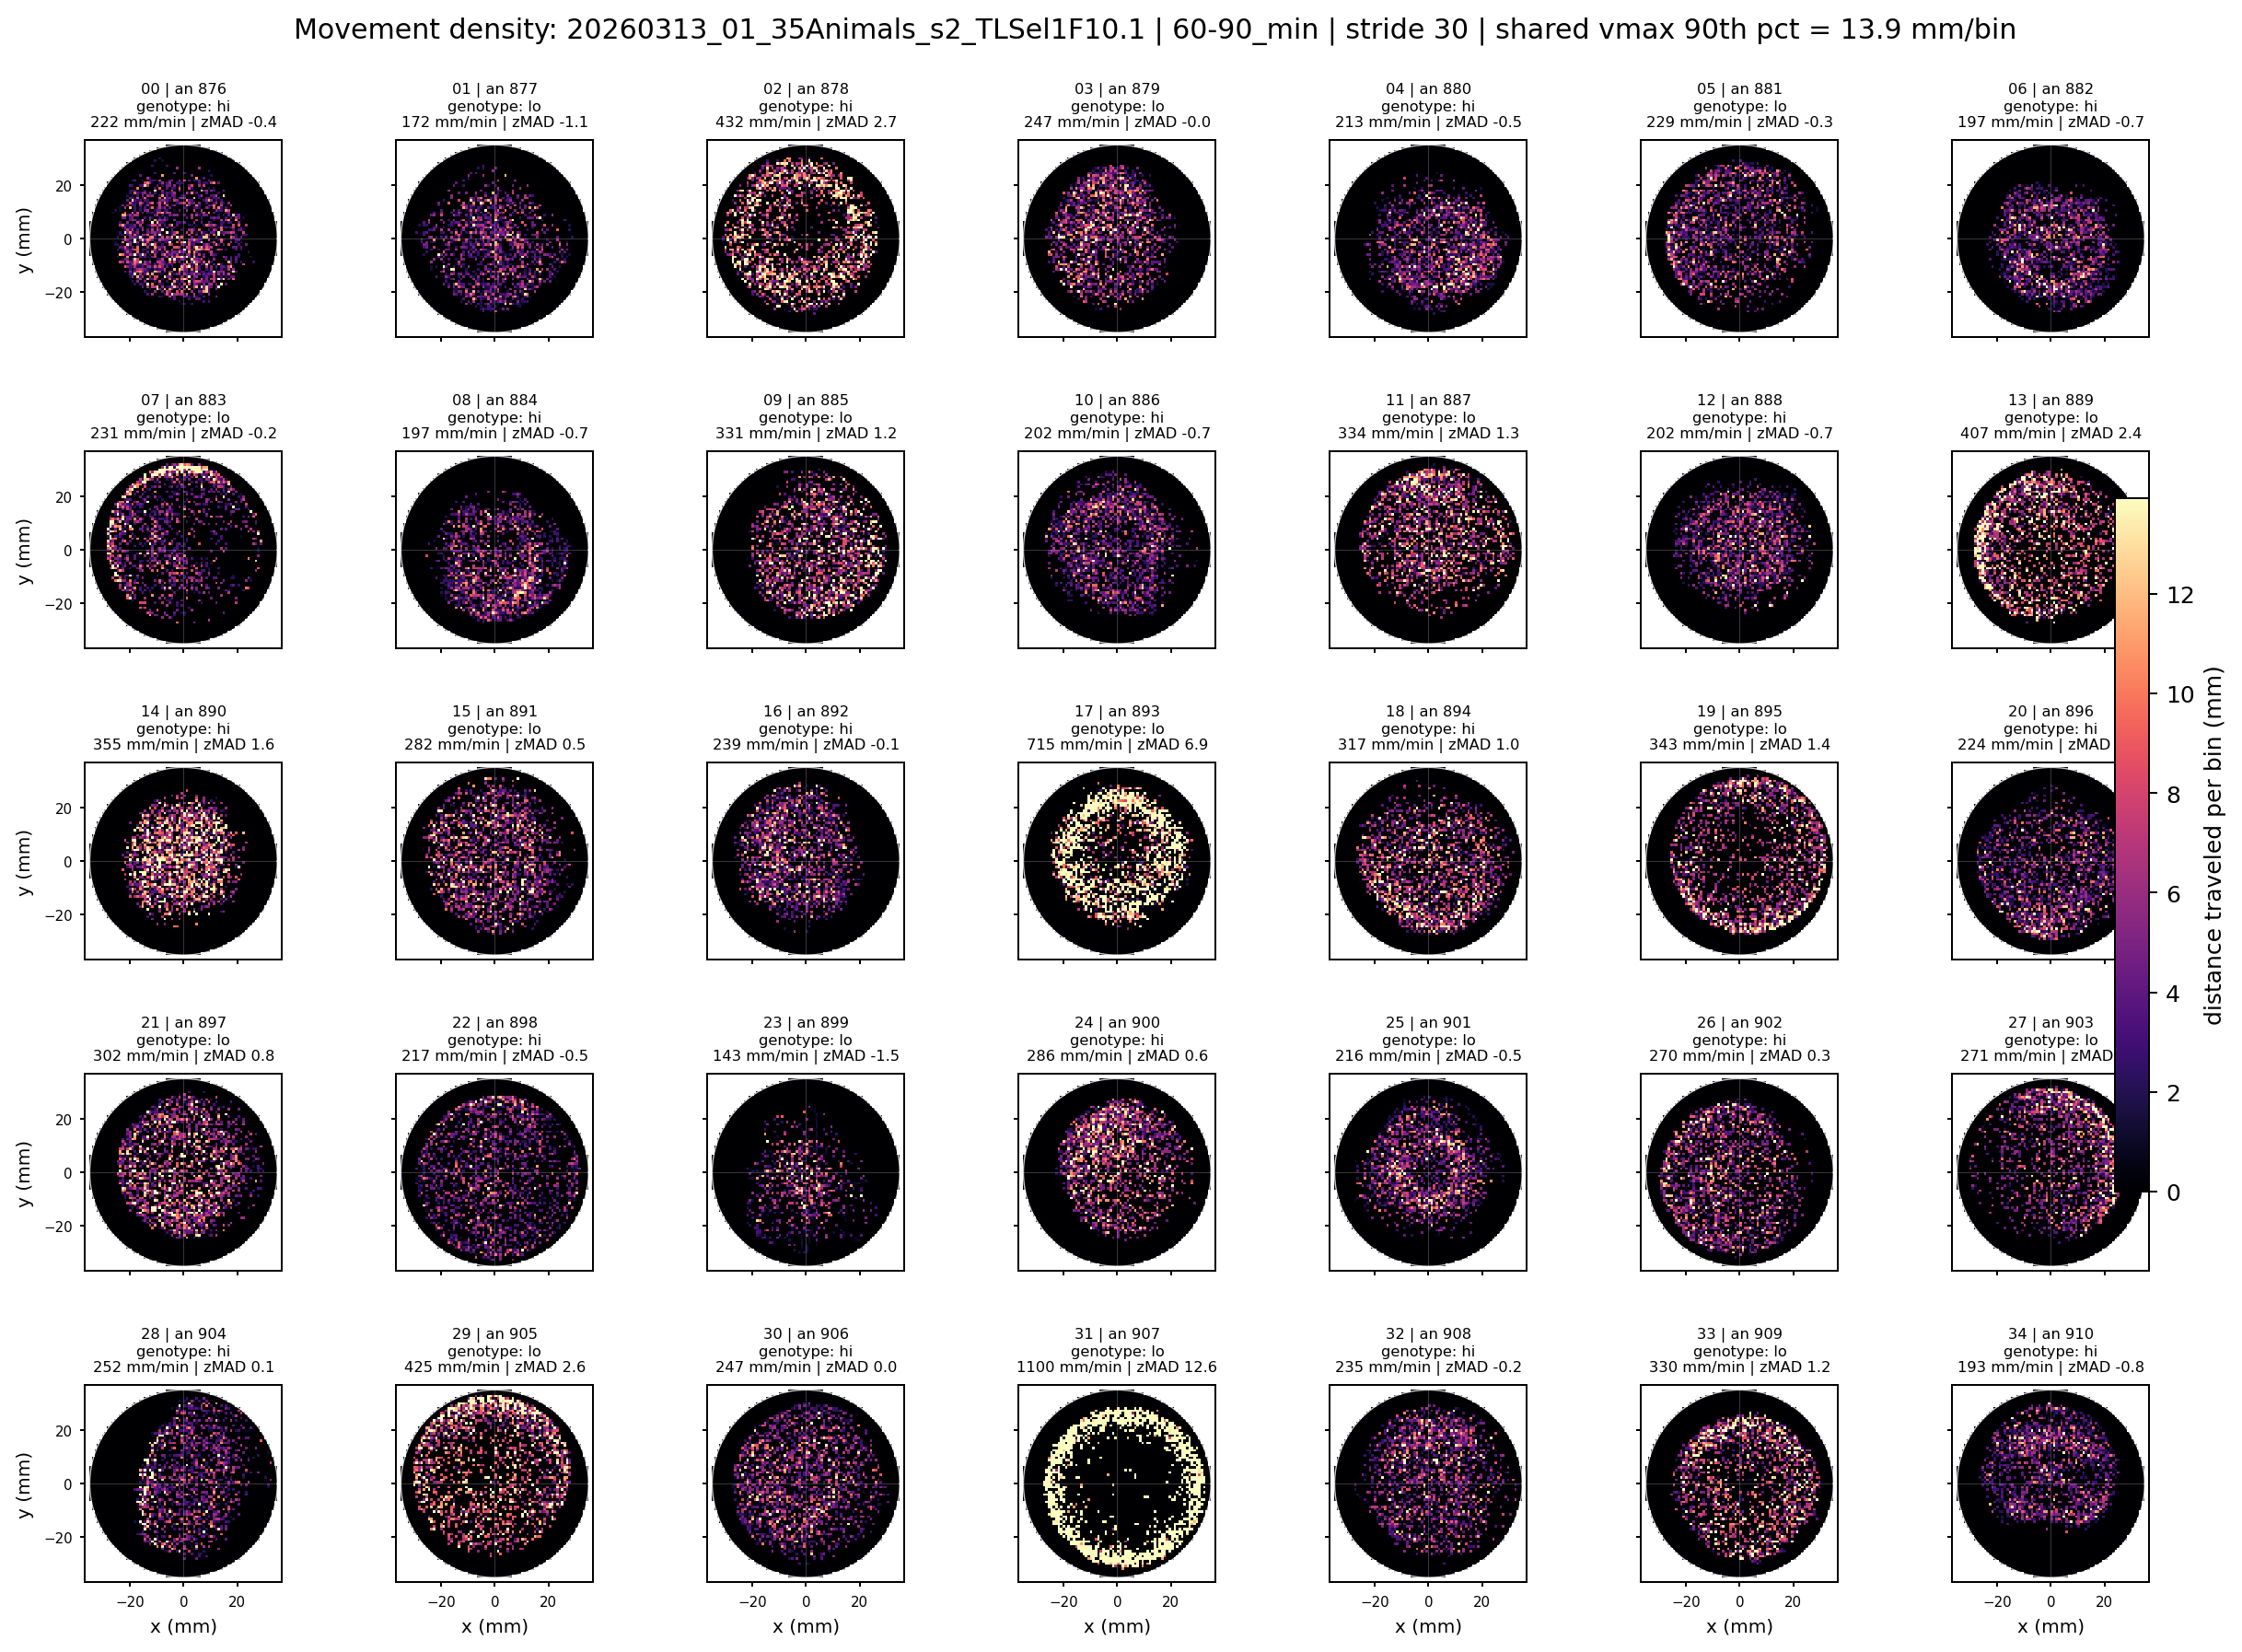

In [13]:
# Generate the heatmap grid and the per-fish metrics table from the trajectory
# window loaded above. If SAVE_FIGURES=True, the helper also writes PNG/PDF
# versions of the grid and a *_metrics.csv copy of movement_metrics.
heatmap_fig, movement_metrics = plot_movement_heatmap_grid(
    xy_mm,
    animal_ids,
    arena_radius_mm,
    trajectory_meta,
    OUTPUT_DIR,
    save_figures=SAVE_FIGURES,
    animal_genotypes=animal_genotypes,
    vmax_percentile=90
)


# Sort by absolute robust deviation so both very high movement and very low
# movement fish rise to the top for manual screening.
# Column meanings:
# - fish_idx: local subplot index in the 5x7 grid.
# - animal_id and genotype: metadata labels for the plotted fish.
# - valid_samples: finite x/y positions in the selected time window.
# - valid_intervals: finite nonzero steps that contributed to distance and heatmap bins.
# - valid_duration_min: valid_intervals converted to elapsed minutes.
# - total_distance_mm: summed valid step distance in the window.
# - distance_per_min and mean_speed_mm_s: movement rate in mm/min and mm/s.
# - arena_coverage_fraction: fraction of in-arena heatmap bins with any movement.
# - movement_z_mad: robust cohort-centered z-score of distance_per_min.
# - movement_z_mad_abs: absolute zMAD used for this outlier ranking.
movement_outliers = movement_metrics.sort_values('movement_z_mad_abs', ascending=False).reset_index(drop=True)
display(movement_outliers)
plt.show()